# Trading bot

In [ ]:
from ib_insync import *
import pandas as pd
import numpy as np
import datetime
import xgboost as xgb
from sklearn.metrics import accuracy_score
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

util.startLoop()  # solo en Jupyter / entornos con event loop activo

# Conectar a IBKR (asegúrate de tener TWS o IB Gateway corriendo)
ib = IB()
ib.connect('127.0.0.1', 4002, clientId=12)  # Ajusta el clientId si es necesario

<IB connected to 127.0.0.1:4002 clientId=12>

Error 1100, reqId -1: Conectividad entre IB y TWS ha sido perdida
Error 1102, reqId -1: Conectividad entre IB y TWS ha sido restaurada - datos mantenidos: Todos los centros de datos est\u00e1n conectados: usfarm; ushmds; secdefil.
Error 10243, reqId 28: No se puede introducir el tama\u00f1o de la orden fraccionado a trav\u00e9s de la API. Utilice la versi\u00f3n de escritorio para revisar esta orden.
Canceled order: Trade(contract=Stock(symbol='GOOG', exchange='SMART', currency='USD'), order=MarketOrder(orderId=28, clientId=12, action='BUY', totalQuantity=0.022222222222222223), orderStatus=OrderStatus(orderId=28, status='Cancelled', filled=0.0, remaining=0.0, avgFillPrice=0.0, permId=0, parentId=0, lastFillPrice=0.0, clientId=0, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 2, 4, 14, 18, 51, 544173, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 2, 4, 14, 18, 51, 67419

In [2]:
# Define el contrato de la acción
symbol = 'GOOG'
contract = Stock(symbol, 'SMART', 'USD')

# Definir fechas para los datos
endDateTime = datetime.datetime.now().strftime("%Y%m%d %H:%M:%S")
durationStr = '2 Y'  # últimos 5 días
barSizeSetting = '15 mins'
whatToShow = 'TRADES'
useRTH = True

# Target
TARGET_IN_BARS_AHEAD = 4

# Inference
PROB_THR = 0.50
CHECK_INTERVAL_MINUTES = 61 # Cada cuanto corre el bucle en minutos
STOP_LOSS_PCT = 0.98  # Stop-loss al 2% por debajo del precio de compra

def log(msg):
    """
    Imprime log con timestamp
    """
    print(f"[{pd.Timestamp.now()}] {msg}")

In [3]:
def getBars():

    # Descargar barras históricas
    bars = ib.reqHistoricalData(
        contract,
        endDateTime=endDateTime,
        durationStr=durationStr,
        barSizeSetting=barSizeSetting,
        whatToShow=whatToShow,
        useRTH=useRTH,
        formatDate=1
    )

    # Convertir bars a DataFrame
    data = []
    for bar in bars:
        dt = pd.Timestamp(bar.date)
        if dt.tzinfo is None:
            dt = dt.tz_localize('US/Eastern')  # Hora de NY (exchange)
        dt = dt.tz_convert('Europe/Madrid')    # Convertir a tu hora local si quieres
        data.append({
            'date': dt,
            'open': bar.open,
            'high': bar.high,
            'low': bar.low,
            'close': bar.close,
            'volume': bar.volume
        })

    df = pd.DataFrame(data)
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    
    return df

## Feature engineering

In [5]:
def createFeatures(data):

    df = data.copy()
    df.sort_index(inplace=True)

    # =========================
    # 1. RETURNS BASE
    # =========================
    df['ret_1'] = df['close'].pct_change()
    df['ret_3'] = df['close'].pct_change(3)
    df['ret_6'] = df['close'].pct_change(6)
    df['ret_12'] = df['close'].pct_change(12)

    # =========================
    # 2. VOLATILIDAD
    # =========================
    df['vol_12'] = df['ret_1'].rolling(12).std()
    df['vol_24'] = df['ret_1'].rolling(24).std()
    df['vol_48'] = df['ret_1'].rolling(48).std()

    # =========================
    # 3. MEDIAS / TENDENCIA LARGA
    # =========================
    for w in [12, 24, 36, 48, 72]:
        df[f'sma_{w}'] = df['close'].rolling(w).mean()
        df[f'dist_sma_{w}'] = (df['close'] - df[f'sma_{w}']) / df[f'sma_{w}']

    # slopes (pendiente tendencia)
    df['slope_24'] = df['sma_24'].diff()
    df['slope_48'] = df['sma_48'].diff()

    # régimen de tendencia
    df['trend_regime'] = (df['sma_24'] > df['sma_48']).astype(int)

    # =========================
    # 4. MOMENTUM / ROC
    # =========================
    df['roc_12'] = df['close'].pct_change(12)
    df['roc_24'] = df['close'].pct_change(24)

    # =========================
    # 5. RSI
    # =========================
    def rsi(series, period=14):
        delta = series.diff()
        up = delta.clip(lower=0)
        down = -delta.clip(upper=0)

        ma_up = up.rolling(period).mean()
        ma_down = down.rolling(period).mean()

        rs = ma_up / ma_down
        return 100 - (100 / (1 + rs))

    df['rsi_14'] = rsi(df['close'], 14)
    df['rsi_28'] = rsi(df['close'], 28)

    # =========================
    # 6. VOLUMEN
    # =========================
    df['vol_mean_24'] = df['volume'].rolling(24).mean()
    df['rel_volume'] = df['volume'] / df['vol_mean_24']

    df['vol_zscore'] = (
        (df['volume'] - df['volume'].rolling(24).mean()) /
        df['volume'].rolling(24).std()
    )

    # OBV (On Balance Volume)
    df['obv'] = (np.sign(df['ret_1']) * df['volume']).fillna(0).cumsum()

    # presión compradora simple
    df['buy_pressure'] = df['ret_1'] * df['volume']

    # =========================
    # 7. FEATURES TEMPORALES (muy útiles intradía)
    # =========================
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute

    # =========================
    # 8. LIMPIEZA
    # =========================
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

## Training stage

In [32]:
# Training
df_raw = getBars()
df = createFeatures(df_raw)
    
# Target: 1 si sube dentro de 12 barras, 0 si no
df['future_close'] = df['close'].shift(-TARGET_IN_BARS_AHEAD)
df['target'] = (df['future_close'] > df['close']).astype(int)

# dropna (no target)
df = df.dropna()

# Features y target
#feature_cols = ['open', 'high', 'low', 'close', 'volume', 'return', 'volatility', 'ma_12', 'ma_24']
X = df.drop(columns=['target', 'future_close'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Importante: no barajamos para series temporales
)

# Inicializar modelo
model = xgb.XGBClassifier(
    n_estimators=500,          # más árboles pero más pequeños
    max_depth=2,              # ↓ MUY importante (reduce varianza)
    learning_rate=0.03,       # ↓ más suave
    subsample=0.6,            # ↓ más randomización
    colsample_bytree=0.6,     # ↓ menos features por árbol
    gamma=2,                  # penaliza splits débiles
    reg_alpha=1,              # L1
    reg_lambda=2,             # L2
    random_state=42,
    eval_metric='logloss'
)

# Entrenar
model.fit(X_train, y_train)

# Evaluar train
y_pred = model.predict(X_train)
acc = accuracy_score(y_train, y_pred)
print(f'Accuracy train: {acc:.4f}')

# Evaluar test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy test: {acc:.4f}')

Accuracy train: 0.6264
Accuracy test: 0.5268


## Model evaluation

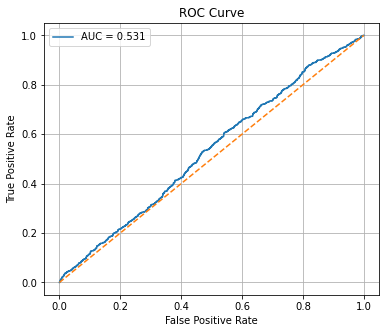

AUC: 0.5306


0.5305777240922219

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_auc(model, X_test, y_test):
    """
    Plotea la curva ROC y devuelve el AUC.
    Compatible con XGBClassifier.
    """

    # Probabilidades clase positiva
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"AUC: {roc_auc:.4f}")
    return roc_auc

plot_roc_auc(model, X_test, y_test)

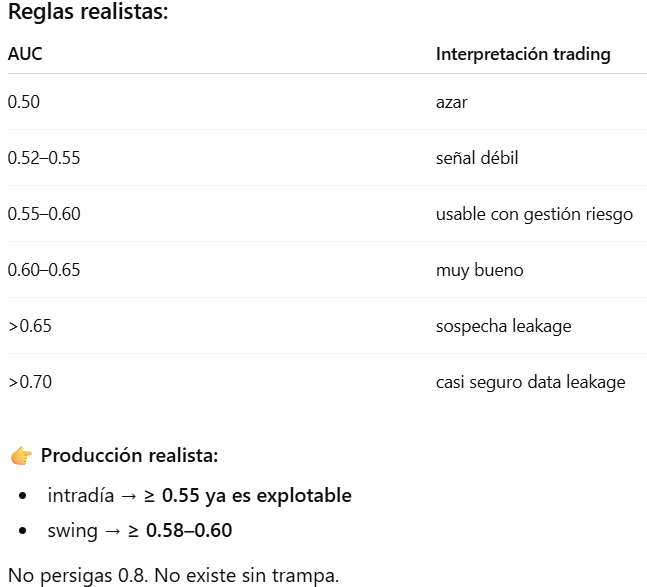

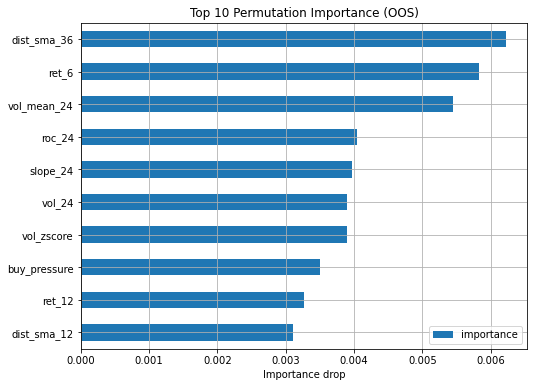

In [ ]:
from sklearn.inspection import permutation_importance

def permutation_importance_top_features(
    model,
    X_test,
    y_test,
    n_top=20,
    n_repeats=5,
    random_state=42,
    plot=True
):
    """
    Calcula permutation importance sobre datos OUT-OF-SAMPLE.

    Parameters
    ----------
    model : modelo entrenado
    X_test : DataFrame
    y_test : array/Series
    n_top : nº de features a devolver
    n_repeats : repeticiones permutation
    plot : mostrar gráfico

    Returns
    -------
    top_features : list[str]
    importances_df : DataFrame ordenado
    """

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importances = pd.Series(
        result.importances_mean,
        index=X_test.columns
    )

    importances_df = (
        importances
        .sort_values(ascending=False)
        .to_frame("importance")
    )

    top_features = importances_df.head(n_top).index.tolist()

    if plot:
        importances_df.head(n_top).sort_values("importance").plot(
            kind="barh",
            figsize=(8,6)
        )
        plt.title(f"Top {n_top} Permutation Importance (OOS)")
        plt.xlabel("Importance drop")
        plt.grid()
        plt.show()

    return top_features, importances_df


top_cols, imp_df = permutation_importance_top_features(
    model,
    X_test,
    y_test,
    n_top=10
)

## Re-train model only with TOP features

Pending....

In [ ]:
import plotly.graph_objects as go

def plot_candles_with_signals(X, y_pred_proba, y_test, PROB_THR):

    df = X.copy().sort_index()

    y_pred_proba = np.asarray(y_pred_proba)

    # ---- prob clase positiva ----
    if y_pred_proba.ndim == 2:
        proba_buy = y_pred_proba[:, 1]
    else:
        proba_buy = y_pred_proba

    y_test = np.asarray(y_test)

    # ---- high/low simulados ----
    high = df['high']
    low  = df['low']

    # ---- señales ----
    signal_mask = proba_buy > PROB_THR

    signal_times = df.index[signal_mask]
    signal_prices = df.loc[signal_mask, 'close']

    # ---- evaluar acierto ----
    correct_mask = y_test[signal_mask] == 1

    times_correct = signal_times[correct_mask]
    prices_correct = signal_prices[correct_mask]

    times_wrong = signal_times[~correct_mask]
    prices_wrong = signal_prices[~correct_mask]

    fig = go.Figure()

    # ======================
    # Velas
    # ======================
    fig.add_trace(
        go.Candlestick(
            x=df.index,
            open=df['open'],
            high=high,
            low=low,
            close=df['close'],
            name="Price"
        )
    )

    # ======================
    # Señales correctas (azul)
    # ======================
    fig.add_trace(
        go.Scatter(
            x=times_correct,
            y=prices_correct,
            mode='markers',
            marker=dict(
                symbol='triangle-up',
                size=12,
                color='blue'
            ),
            name='Buy correct'
        )
    )

    # ======================
    # Señales incorrectas (negro)
    # ======================
    fig.add_trace(
        go.Scatter(
            x=times_wrong,
            y=prices_wrong,
            mode='markers',
            marker=dict(
                symbol='triangle-up',
                size=12,
                color='black'
            ),
            name='Buy wrong'
        )
    )

    fig.update_layout(
        title=f"Señales compra (azul=acierto | negro=fallo)",
        xaxis_rangeslider_visible=False,
        height=650
    )

    fig.show()

    # ======================
    # Métricas rápidas
    # ======================
    n_trades = signal_mask.sum()
    if n_trades > 0:
        winrate = correct_mask.mean()
        print(f"Trades: {n_trades}")
        print(f"Accuracy señales: {winrate:.2%}")

plot_candles_with_signals(X_test, y_pred_proba, y_test, PROB_THR)

Trades: 2409
Accuracy señales: 52.39%


In [ ]:

def evaluate_threshold_strategy(
    X,
    y_pred_proba,
    y_test,
    PROB_THR,
    horizon=4,
    initial_cash=10_000
):
    """
    Evalúa señales de compra y calcula métricas + rentabilidad.

    Returns
    -------
    summary : pd.DataFrame
    trades  : pd.DataFrame
    """

    df = X.copy().sort_index()

    y_pred_proba = np.asarray(y_pred_proba)
    y_test = np.asarray(y_test)

    # ---- prob clase positiva ----
    if y_pred_proba.ndim == 2:
        proba_buy = y_pred_proba[:, 1]
    else:
        proba_buy = y_pred_proba

    closes = df['close'].values

    # =========================
    # Señales
    # =========================
    signal_mask = proba_buy > PROB_THR
    signal_idx = np.where(signal_mask)[0]

    trades = []

    for i in signal_idx:

        if i + horizon >= len(closes):
            continue

        entry_price = closes[i]
        exit_price = closes[i + horizon]

        ret = (exit_price - entry_price) / entry_price
        correct = (y_test[i] == 1)

        trades.append([
            df.index[i],
            df.index[i + horizon],
            entry_price,
            exit_price,
            ret,
            correct
        ])

    trades = pd.DataFrame(
        trades,
        columns=[
            'entry_time',
            'exit_time',
            'entry_price',
            'exit_price',
            'ret',
            'correct'
        ]
    )

    # =========================
    # Métricas clasificación
    # =========================
    n_trades = len(trades)
    tp = trades['correct'].sum()
    fp = n_trades - tp

    precision = tp / n_trades if n_trades else 0
    coverage = n_trades / len(df)

    # =========================
    # Equity curve
    # =========================
    equity = initial_cash
    equity_curve = []

    for r in trades['ret']:
        equity *= (1 + r)
        equity_curve.append(equity)

    trades['equity'] = equity_curve

    final_cash = equity
    pnl_eur = final_cash - initial_cash
    pnl_pct = pnl_eur / initial_cash

    # =========================
    # Tabla resumen
    # =========================
    summary = pd.DataFrame({
        "metric": [
            "threshold",
            "total_bars",
            "signals_taken",
            "coverage_%",
            "correct",
            "wrong",
            "precision_% (hit rate)",
            "avg_return_per_trade_%",
            "final_equity_€",
            "pnl_€",
            "pnl_%"
        ],
        "value": [
            PROB_THR,
            len(df),
            n_trades,
            round(coverage * 100, 2),
            int(tp),
            int(fp),
            round(precision * 100, 2),
            round(trades['ret'].mean() * 100 if n_trades else 0, 3),
            round(final_cash, 2),
            round(pnl_eur, 2),
            round(pnl_pct * 100, 2)
        ]
    })

    print("\n===== BACKTEST SUMMARY =====")
    print(summary.to_string(index=False))

    return summary, trades

summary, trades = evaluate_threshold_strategy(
    X_test,
    y_pred_proba,
    y_test,
    PROB_THR,
    TARGET_IN_BARS_AHEAD,
    initial_cash=1000
)


===== BACKTEST SUMMARY =====
                metric    value
             threshold    0.500
            total_bars 2570.000
         signals_taken 2407.000
            coverage_%   93.660
               correct 1260.000
                 wrong 1147.000
precision_% (hit rate)   52.350
avg_return_per_trade_%    0.038
        final_equity_€ 2410.560
                 pnl_€ 1410.560
                 pnl_%  141.060


## Save model

In [38]:
import joblib

joblib.dump(model, 'xgb_model_ibkr.pkl')
print("Modelo guardado en xgb_model_ibkr.pkl")

Modelo guardado en xgb_model_ibkr.pkl


In [39]:
# Cargar modelo
model = joblib.load('xgb_model_ibkr.pkl')
print("Modelo cargado correctamente")

Modelo cargado correctamente


## Trading functions

In [31]:
def place_buy_order(qty=1, stop_pct=0.02):

    order = MarketOrder('BUY', qty)
    trade = ib.placeOrder(contract, order)

    # esperar hasta que esté filled
    while not trade.isDone():
        ib.waitOnUpdate()

    if not trade.fills:
        raise RuntimeError("La orden no se ejecutó")

    fill_price = trade.fills[0].execution.price
    stop_price = round(fill_price * (1 - stop_pct), 2)

    stop = StopOrder('SELL', qty, stop_price)
    ib.placeOrder(contract, stop)

    log(f"Comprado a {fill_price:.2f} | Stop colocado en {stop_price:.2f}")

    return trade

def place_sell_order(qty=1):
    # Orden de venta
    order = MarketOrder('SELL', qty)
    trade = ib.placeOrder(contract, order)
    log(f"Orden de venta enviada: {trade}")


def has_open_position():
    """
    Devuelve True si hay alguna posición abierta en el símbolo indicado, False si no.
    """
    contract = Stock(symbol, 'SMART', 'USD')
    ib.qualifyContracts(contract)
    
    positions = ib.positions()  # lista de todas las posiciones abiertas
    for pos in positions:
        if pos.contract.conId == contract.conId and pos.position != 0:
            return True
    return False

def close_all_positions():
    """
    Cierra todas las posiciones abiertas del símbolo indicado.
    
    ib: instancia de IB() conectada
    symbol: ticker del activo (ej: 'AAPL', 'GOOG')
    
    Devuelve:
        Listado de dicts con resumen de cierre:
        [{'action': 'SELL', 'qty': 10, 'symbol': 'GOOG', 'status': 'filled'}, ...]
    """

    summary = []
    
    # Obtener posiciones abiertas de ese símbolo
    positions = [p for p in ib.positions() if p.contract.symbol == symbol]

    if not positions:
        print(f"No hay posiciones abiertas de {symbol}")
        return summary

    for pos in positions:
        qty = pos.position
        if qty == 0:
            continue

        # Determinar acción
        action = 'SELL' if qty > 0 else 'BUY'
        order_qty = abs(qty)

        # Crear contrato usando SMART routing para evitar error 10311
        contract = Stock(symbol, 'SMART', 'USD')
        order = MarketOrder(action, order_qty)

        try:
            trade = ib.placeOrder(contract, order)
            log(f"[{symbol}] Orden enviada: {action} {order_qty}")

            # Esperar a que la orden se complete
            while not trade.isDone():
                ib.sleep(0.5)

            log
            (f"[{symbol}] Posición cerrada: {action} {order_qty}")
            summary.append({'symbol': symbol, 'action': action, 'qty': order_qty, 'status': 'filled'})
        except Exception as e:
            log(f"[{symbol}] Error al cerrar posición: {e}")
            summary.append({'symbol': symbol, 'action': action, 'qty': order_qty, 'status': f'error: {e}'})

    log(f"Todas las posiciones de {symbol} han sido procesadas.")
    return summary

## Production loop

In [ ]:
while True:
    # Inference mode
    last_bars = getBars()
    X_latest = createFeatures(last_bars).iloc[-1:]
    price = X_latest['close'][0]

    # Close all
    close_all_positions()
    
    # Predict
    proba = model.predict_proba(X_latest)[0][1]    
    log("Latest bar:{} at price {} with probability {:.4f}".format(X_latest.index.format(), price, proba))

    if proba > PROB_THR:
        log("Execute buy order")
        place_buy_order()
        entry_time = pd.Timestamp.utcnow().tz_convert('Europe/Madrid') # Save entry time
    
    else:
        log("No buy, low probability")

    time.sleep(CHECK_INTERVAL_MINUTES * 60)

No hay posiciones abiertas de GOOG
[2026-02-02 20:12:07.549812] Latest bar:['2026-02-02 19:45:00+01:00'] at price 344.07 with probability 0.6584
[2026-02-02 20:12:07.549812] Execute buy order
[2026-02-02 20:12:08.028426] Comprado a 344.04 | Stop colocado en 337.16
[GOOG] Orden enviada: SELL 1.0
[GOOG] Posición cerrada: SELL 1.0
Todas las posiciones de GOOG han sido procesadas.
[2026-02-02 20:45:33.790050] Latest bar:['2026-02-02 20:00:00+01:00'] at price 344.34 with probability 0.5665
[2026-02-02 20:45:33.790050] Execute buy order
[2026-02-02 20:45:34.468649] Comprado a 343.86 | Stop colocado en 336.98


In [ ]:
# Vender todo antes del cierre de mercado